<a href="https://colab.research.google.com/github/veronicaluzzi/Data-Science-Cohort-20/blob/main/Project-6/All_Images_trial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Images – To Do List



Prior to starting this problem, be sure to enable the GPU runtime processing in your Jupyter notebook.



## Problem Definition


Design a deep learning model able to differentiate a picture of a cat from a picture of a dog with higher than 75% confidence.

In [ ]:
import tensorflow.keras as keras
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import requests
from io import BytesIO
from tensorflow.keras.preprocessing import image



## Data Collection



* Load pickled data from X.pickle and y.pickle from the AWS S3 bucket.



In [ ]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [ ]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [ ]:
image_array.shape

(24946, 100, 100, 1)

In [ ]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [ ]:
target = pd.read_pickle( target_url )
type(target)


list

In [ ]:
# 1. Convert the entire target list to a NumPy array
target_array = np.array(target)

# 2. Create a randomized index mask based on the full dataset length
np.random.seed(42)  # Setting a seed ensures you get the exact same "random" shuffle every time you run it
shuffled_indices = np.random.permutation(len(image_array))

# 3. Shuffle the full datasets using the randomized indices
X_shuffled = image_array[shuffled_indices]
y_shuffled = target_array[shuffled_indices]

# 4. Now slice your 1,000 image subset from the shuffled data
X_toy = X_shuffled[:1000]
y_toy = y_shuffled[:1000]

# 5. Sanity check the types, shapes, and new label distribution
print("y_toy type:", type(y_toy))
print("X_toy shape:", X_toy.shape)
print("y_toy shape:", y_toy.shape)

# Let's see what the new label breakdown looks like!
unique_labels, counts = np.unique(y_toy, return_counts=True)
print("Shuffled label distribution:", dict(zip(unique_labels, counts)))

y_toy type: <class 'numpy.ndarray'>
X_toy shape: (1000, 100, 100, 1)
y_toy shape: (1000,)
Shuffled label distribution: {np.int64(0): np.int64(498), np.int64(1): np.int64(502)}


In [ ]:
# Count how many of each unique label exist in your toy set
unique_labels, counts = np.unique(y_toy, return_counts=True)
print(dict(zip(unique_labels, counts)))

{np.int64(0): np.int64(498), np.int64(1): np.int64(502)}


## Data Cleaning



* Scale the values in X so that they fall between 0 and 1 by dividing by 255.



In [ ]:
# Scale the values in X_toy to fall between 0 and 1
X_toy_scaled = X_toy / 255.0

# Quick sanity check to verify the new range
print("Original min/max: ", X_toy.min(), "to", X_toy.max())
print("Scaled min/max:   ", X_toy_scaled.min(), "to", X_toy_scaled.max())
print("Scaled data type: ", X_toy_scaled.dtype)

Original min/max:  0 to 255
Scaled min/max:    0.0 to 1.0
Scaled data type:  float64


## Exploratory Data Analysis



* Look at the shape of X and y. Ensure that X is 4 dimensional.

* Plot a few ( >5 ) of the images in X using `plt.imshow()`.

* Look at the response values in y for those images.

* Hint: you may want to start with a random subset to get familiar with the process of building a NN.  Then go through the process again with the full set.



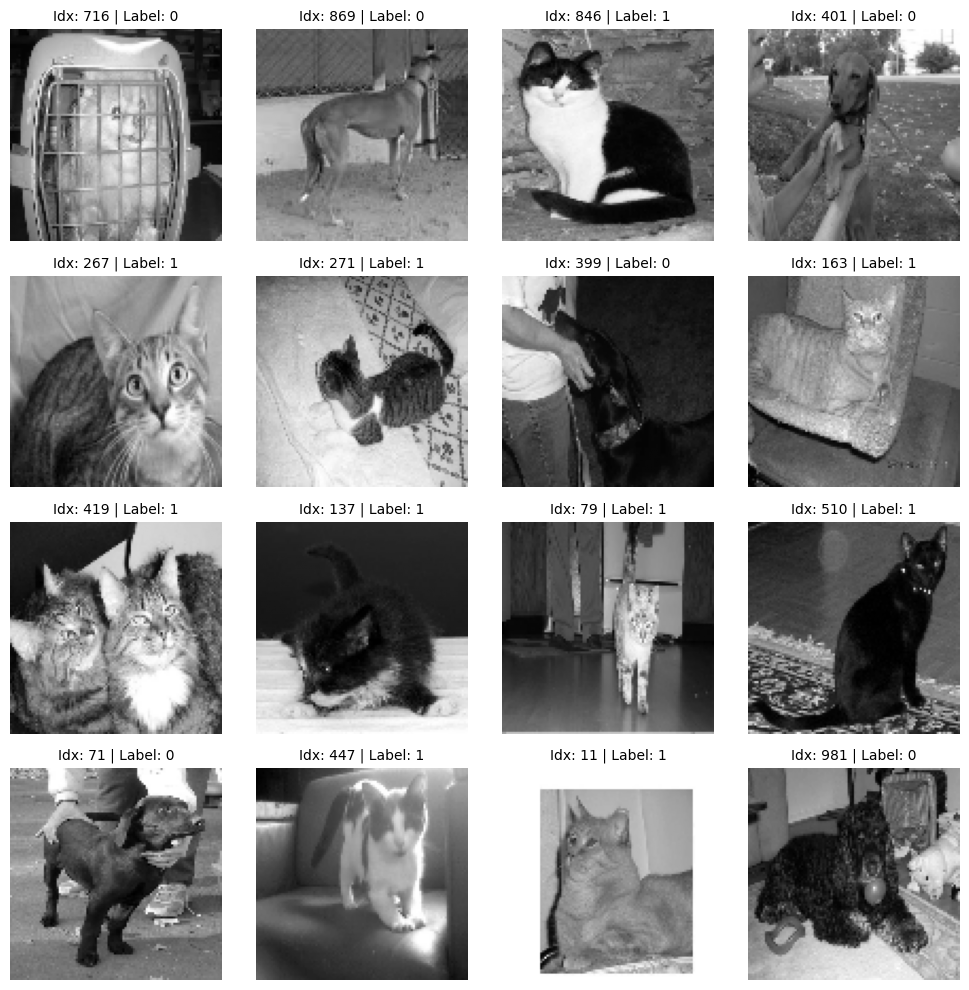

In [ ]:
# 1. Choose how many images to look at (e.g., a 4x4 grid)
rows, cols = 4, 4
num_images = rows * cols

# 2. Pick random indices from the toy dataset
# np.random.seed(40) # Change this number to look at a completely different batch of images next time
random_toy_indices = np.random.choice(len(X_toy_scaled), size=num_images, replace=False)

# 3. Set up the matplotlib figure
fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    # Get the actual index from our random selection
    img_idx = random_toy_indices[i]

    # Grab the image and its corresponding label
    img = X_toy_scaled[img_idx]
    label = y_toy[img_idx]

    # Plot the image
    # Note: If your image shape is 2D (flattened), we will need to reshape it here first!
    # Force matplotlib to use a grayscale colormap
    ax.imshow(img, cmap='gray')

    # Label the subplot with its index and target value
    ax.set_title(f"Idx: {img_idx} | Label: {label}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

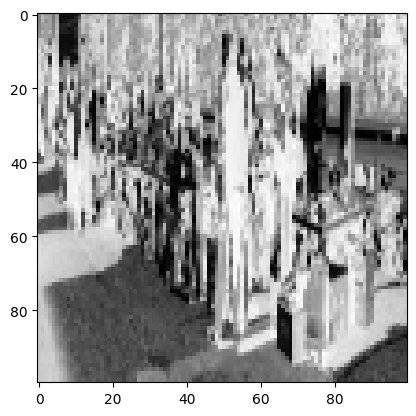

In [ ]:
plt.imshow( X_toy_scaled[755], cmap = plt.cm.gray_r )
plt.show()

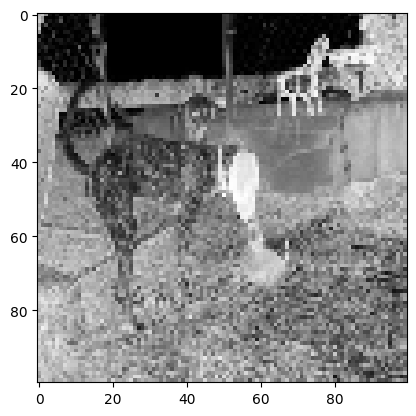

In [ ]:
plt.imshow( X_toy_scaled[678], cmap = plt.cm.gray_r )
plt.show()

In [ ]:
# See the response for that sample
y_toy[265]

np.int64(0)

## Data Processing



* Split X and y into training and testing sets.

*  Build a convolutional neural network with the following:
  * Sequential layers
  * At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.
  * A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).
  * A dense output layer using the 'sigmoid' activation function.
  Note: you can play around with the number of layers and nodes to try to get better performance.

* Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

* Fit your model using the training set.

* Evaluate your model using the testing set.

* Plot the distribution of probabilities for the testing set.

* Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: [numpy.reshape]( https://numpy.org/doc/stable/reference/generated/numpy.reshape.html )

* Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

* Use the neural network you created to predict whether the image is a dog or a cat.




* Communicate the results of your analysis.



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# --- 1. PREPARE THE FULL DATASETS ---
# Using the arrays already loaded in your session from the S3 pickling step
target_array = np.array(target)

# Shuffle the entire dataset once to keep distributions uniform
np.random.seed(42)
shuffled_indices = np.random.permutation(len(image_array))
X_all_shuffled = image_array[shuffled_indices]
y_all_shuffled = target_array[shuffled_indices]

# Define Early Stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# --- 2. THE INCREMENTAL LOOP ---
for size in dataset_sizes:
    print(f"\n" + "="*50)
    print(f"TRAINING MODEL WITH DATASET SIZE: {size} IMAGES")
    print("="*50)

    # Slice the current increment chunk
    X_chunk = X_all_shuffled[:size]
    y_chunk = y_all_shuffled[:size]

    # Train-test split (80/20 split matching your notebook)
    X_train, X_test, y_train, y_test = train_test_split(
        X_chunk, y_chunk, test_size=0.20, stratify=y_chunk, random_state=42
    )

    # [FIXED] Restored the crucial scaling step here
    X_train_scaled = (X_train / 255.0).astype(np.float32)
    X_test_scaled = (X_test / 255.0).astype(np.float32)

    # Re-build fresh CPU-optimized model instance with regularization
    model = models.Sequential([
        layers.Input(shape=(100, 100, 1)),

        # --- Data Augmentation Layer ---
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        # -------------------------------

        # [FIXED] Completed the missing Block 1 code
        # Block 1
        layers.Conv2D(16, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # [FIXED] Indented model.fit back INTO the loop
    # Train with the callback added
    model.fit(
        X_train_scaled, y_train,
        epochs=15,
        batch_size=64,
        validation_data=(X_test_scaled, y_test),
        callbacks=[early_stopping],
        verbose=1
    )

    # [FIXED] Indented predictions, summary, and evaluation back INTO the loop
    # Save predictions on the test set for our 3D visual distribution mapping
    preds = model.predict(X_test_scaled, verbose=0)
    all_probabilities[size] = preds.flatten()

    model.summary()

    # [FIXED] Evaluating on X_test_scaled instead of unscaled X_test
    test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
    print(f"Testing Accuracy: {test_accuracy:.4f}")
    print(f"Testing Loss: {test_loss:.4f}")


TRAINING MODEL WITH DATASET SIZE: 4000 IMAGES
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 51s 926ms/step - accuracy: 0.5688 - loss: 0.8874 - val_accuracy: 0.5075 - val_loss: 0.7485
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 46s 918ms/step - accuracy: 0.5784 - loss: 0.7864 - val_accuracy: 0.5013 - val_loss: 1.0206
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 909ms/step - accuracy: 0.5903 - loss: 0.7403 - val_accuracy: 0.5013 - val_loss: 0.8630
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 888ms/step - accuracy: 0.6006 - loss: 0.7044 - val_accuracy: 0.5250 - val_loss: 0.7199
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 848ms/step - accuracy: 0.6194 - loss: 0.6857 - val_accuracy: 0.5063 - val_loss: 0.8357
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 45s 912ms/step - accuracy: 0.6225 - loss: 0.6833 - val_accuracy: 0.5500 - val_loss: 0.6948
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 44s 889ms/step - accuracy: 0.6084 - loss: 0.6910 - val_accuracy: 0.5713 - val_loss: 0.6923
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 43s 863ms/st

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_8 (RandomFlip)      │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_8               │ (None, 100, 100, 1)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_8 (RandomZoom)      │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 98, 98, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 98, 98, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 47, 47, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │     1,083,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265,861 (12.46 MB)

 Trainable params: 1,088,545 (4.15 MB)

...

 Total params: 3,265,861 (12.46 MB)

 Trainable params: 1,088,545 (4.15 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 2,177,092 (8.30 MB)

150/150 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.5263 - loss: 1.5407
Testing Accuracy: 0.5263
Testing Loss: 1.5407


In [ ]:
all_probabilities.keys()

dict_keys([4000, 8000, 12000, 16000, 20000, 24000])

In [ ]:
# --- 3. TEST PREDICTION WITH A NEW IMAGE ---

# URL of the test dog image provided
test_dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

def predict_new_image_from_url(url, trained_model, target_height=100, target_width=100):
    """
    Downloads an image, converts it to grayscale, scales it,
    and predicts its class using the freshly trained model.
    """
    # 1. Download the image from the web
    response = requests.get(url)

    # 2. Load it as a PIL image in GRAYSCALE to match our 1-channel network architecture
    img = image.load_img(
        BytesIO(response.content),
        target_size=(target_height, target_width),
        color_mode='grayscale'
    )

    # 3. Convert to a 3D NumPy array (100, 100, 1) and scale pixels to [0, 1]
    img_array = image.img_to_array(img)
    img_array_scaled = (img_array / 255.0).astype(np.float32)

    # 4. Expand dimensions to create a 4D tensor: (1, 100, 100, 1)
    img_tensor = np.expand_dims(img_array_scaled, axis=0)

    # 5. Run the prediction through the trained model
    # verbose=0 keeps the notebook output clean
    prediction_score = trained_model.predict(img_tensor, verbose=0)[0][0]

    # 6. Output a clean, human-readable layout
    print("\n" + "="*40)
    print("      NEW IMAGE PREDICTION VERDICT      ")
    print("="*40)
    print(f"Raw Output Probability: {prediction_score:.4f}")

    # Keras defaults to alphabetical sorting: 0 = cats, 1 = dogs
    if prediction_score >= 0.5:
        confidence = prediction_score * 100
        print(f"🐶 Verdict: DOG (Class 1) with {confidence:.2f}% confidence.")
    else:
        confidence = (1 - prediction_score) * 100
        print(f"🐱 Verdict: CAT (Class 0) with {confidence:.2f}% confidence.")
    print("="*40)

# Run the prediction using the final model state from the loop
predict_new_image_from_url(test_dog_url, trained_model=model)


      NEW IMAGE PREDICTION VERDICT      
Raw Output Probability: 0.8104
🐶 Verdict: DOG (Class 1) with 81.04% confidence.


In [ ]:
import numpy as np
import plotly.graph_objects as go

# 1. Create a common grid of probability bins (X-axis)
# Setting 40 bins between 0.0 and 1.0
bin_edges = np.linspace(0.0, 1.0, 41)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

# 2. Build the data matrix for the 3D grid
z_matrix = []
y_dataset_sizes = sorted(list(all_probabilities.keys()))

for size in y_dataset_sizes:
    # Get the raw list of test probabilities for the current slice
    preds = all_probabilities[size]

    # Compute the frequency distribution matching our fixed bins
    counts, _ = np.histogram(preds, bins=bin_edges)

    # Normalize the counts so different size validation steps are directly comparable
    normalized_density = counts / len(preds)
    z_matrix.append(normalized_density)

z_matrix = np.array(z_matrix)

# 3. Create the Plotly 3D Figure
fig = go.Figure(data=[go.Surface(
    x=bin_centers,
    y=y_dataset_sizes,
    z=z_matrix,
    colorscale='Viridis',
    colorbar=dict(title='Probability Density')
)])

# 4. Enhance aesthetics and layout constraints
fig.update_layout(
    title='Testing Probability Distribution Shift Across Incremental Dataset Sizes',
    scene=dict(
        xaxis=dict(title='Predicted Probability (Cat vs Dog)', range=[0, 1]),
        yaxis=dict(title='Dataset Sample Size', tickvals=y_dataset_sizes),
        zaxis=dict(title='Normalized Density Fraction'),
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.2)) # Sets a clean initial perspective angle
    ),
    autosize=False,
    width=900,
    height=700,
    margin=dict(l=65, r=50, b=65, t=90)
)

# Display interactive plot
fig.show()

4000


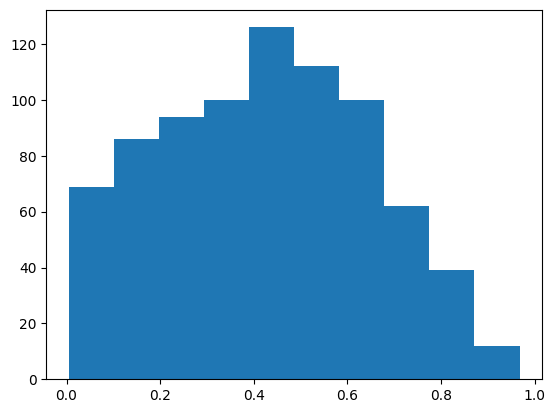

8000


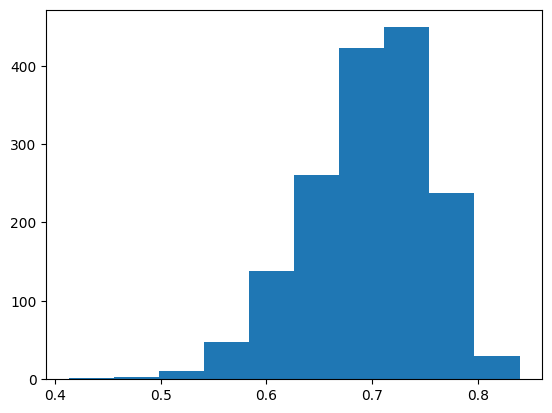

12000


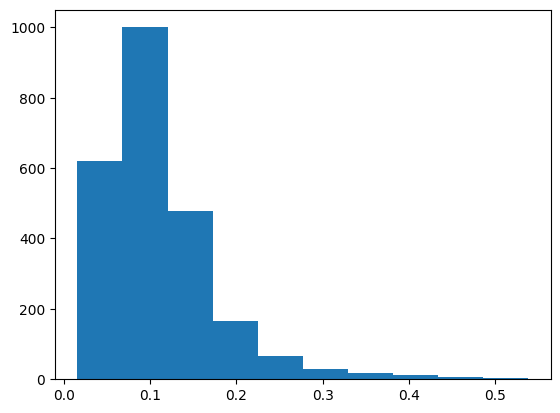

16000


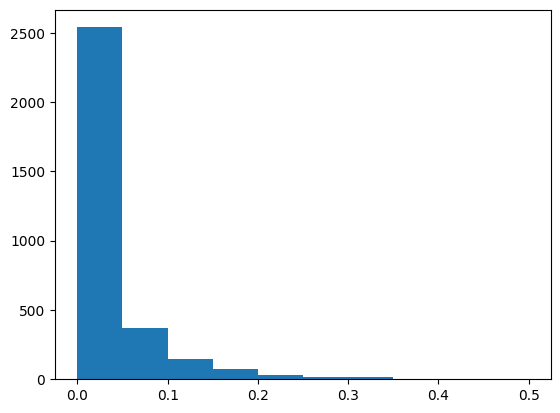

20000


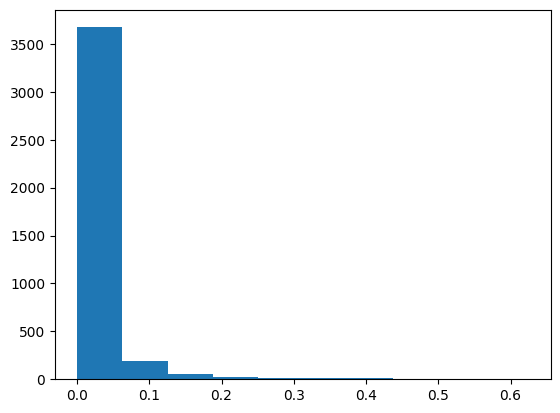

24000


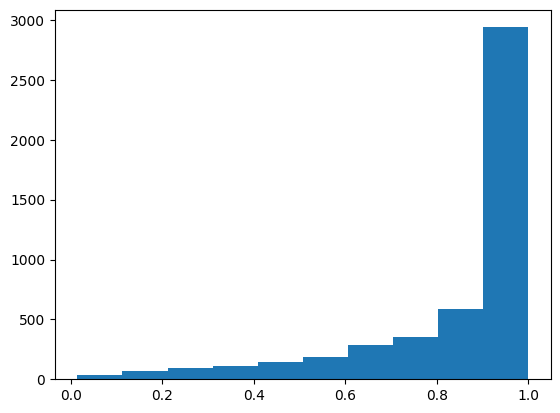

In [ ]:
for i in all_probabilities.keys():
  print(i)
  plt.hist(all_probabilities[i])
  plt.show()


In [ ]:
# --- 3. TEST PREDICTION WITH A NEW IMAGE ---

# URL of the test dog image provided
test_dog_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"

def predict_new_image_from_url(url, trained_model, target_height=100, target_width=100):
    """
    Downloads an image, converts it to grayscale, scales it,
    and predicts its class using the freshly trained model.
    """
    # 1. Download the image from the web
    response = requests.get(url)

    # 2. Load it as a PIL image in GRAYSCALE to match our 1-channel network architecture
    img = image.load_img(
        BytesIO(response.content),
        target_size=(target_height, target_width),
        color_mode='grayscale'
    )

    # 3. Convert to a 3D NumPy array (100, 100, 1) and scale pixels to [0, 1]
    img_array = image.img_to_array(img)
    img_array_scaled = (img_array / 255.0).astype(np.float32)

    # 4. Expand dimensions to create a 4D tensor: (1, 100, 100, 1)
    img_tensor = np.expand_dims(img_array_scaled, axis=0)

    # 5. Run the prediction through the trained model
    # verbose=0 keeps the notebook output clean
    prediction_score = trained_model.predict(img_tensor, verbose=0)[0][0]

    # 6. Output a clean, human-readable layout
    print("\n" + "="*40)
    print("      NEW IMAGE PREDICTION VERDICT      ")
    print("="*40)
    print(f"Raw Output Probability: {prediction_score:.4f}")

    # Keras defaults to alphabetical sorting: 0 = cats, 1 = dogs
    if prediction_score >= 0.5:
        confidence = prediction_score * 100
        print(f"🐶 Verdict: DOG (Class 1) with {confidence:.2f}% confidence.")
    else:
        confidence = (1 - prediction_score) * 100
        print(f"🐱 Verdict: CAT (Class 0) with {confidence:.2f}% confidence.")
    print("="*40)

# Run the prediction using the final model state from the loop
predict_new_image_from_url(test_dog_url, trained_model=model)


      NEW IMAGE PREDICTION VERDICT      
Raw Output Probability: 0.8104
🐶 Verdict: DOG (Class 1) with 81.04% confidence.


## Communication of Results


## **BONUS** (optional)



* Upload an image of your (or your friend's or family's) dog or cat and use your model to predict whether the image is a dog or cat.
* Hint: you'll probably need to convert the image from color to grayscale.  OpenCV, pillow, and other libraries are your friend.